In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
df = pd.read_csv("superstore.csv")

In [24]:
# Q1: DATA CLEANING
# Count missing values
missing_values = df.isnull().sum()
print(missing_values)

df = df.dropna()


Category          0
City              0
Country           0
Customer.ID       0
Customer.Name     0
Discount          0
Market            0
记录数               0
Order.Date        0
Order.ID          0
Order.Priority    0
Product.ID        0
Product.Name      0
Profit            0
Quantity          0
Region            0
Row.ID            0
Sales             0
Segment           0
Ship.Date         0
Ship.Mode         0
Shipping.Cost     5
State             3
Sub.Category      0
Year              0
Market2           0
weeknum           0
dtype: int64


In [25]:
# Count duplicates
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

# Remove duplicates
df = df.drop_duplicates()

Duplicate rows: 0


In [26]:
# standardize column names
df.columns = df.columns.str.strip().str.lower().str.replace(".", "_")

# Drop irrelevant/unknown columns
cols_to_drop = ['记录数', 'market2']   # based on your dataset
df.drop(columns=[col for col in cols_to_drop if col in df.columns], inplace=True)

# Shape
print("Shape:", df.shape)

# Size
print("Size:", df.size)

# Datatypes
print(df.dtypes)

# Convert date columns
df['order_date'] = pd.to_datetime(df['order_date'])
df['ship_date'] = pd.to_datetime(df['ship_date'])

Shape: (51282, 25)
Size: 1282050
category           object
city               object
country            object
customer_id        object
customer_name      object
discount          float64
market             object
order_date         object
order_id           object
order_priority     object
product_id         object
product_name       object
profit            float64
quantity            int64
region             object
row_id              int64
sales               int64
segment            object
ship_date          object
ship_mode          object
shipping_cost     float64
state              object
sub_category       object
year                int64
weeknum             int64
dtype: object


           discount        profit      quantity        row_id         sales  \
count  51282.000000  51282.000000  51282.000000  51282.000000  51282.000000   
mean       0.142930     28.613718      3.476814  25643.883370    246.532292   
std        0.212289    174.354364      2.278827  14806.835995    487.597516   
min        0.000000  -6599.978000      1.000000      1.000000      0.000000   
25%        0.000000      0.000000      2.000000  12821.250000     31.000000   
50%        0.000000      9.240000      3.000000  25641.500000     85.000000   
75%        0.200000     36.810000      5.000000  38467.750000    251.000000   
max        0.850000   8399.976000     14.000000  51290.000000  22638.000000   

       shipping_cost          year      weeknum  
count   51282.000000  51282.000000  51282.00000  
mean       26.379537   2012.777271     31.28743  
std        57.300496      1.098918     14.42950  
min         0.002000   2011.000000      1.00000  
25%         2.610000   2012.000000    

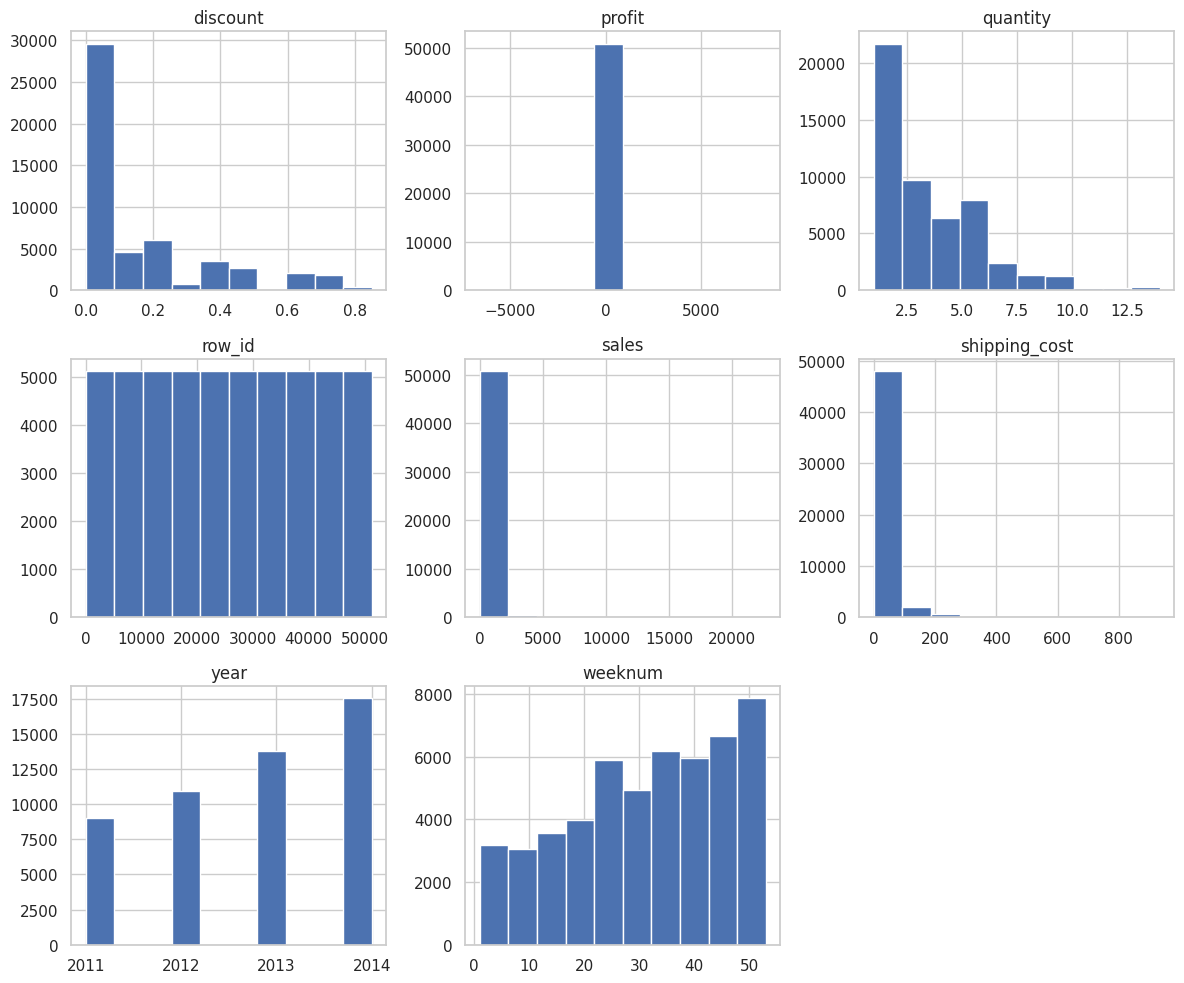

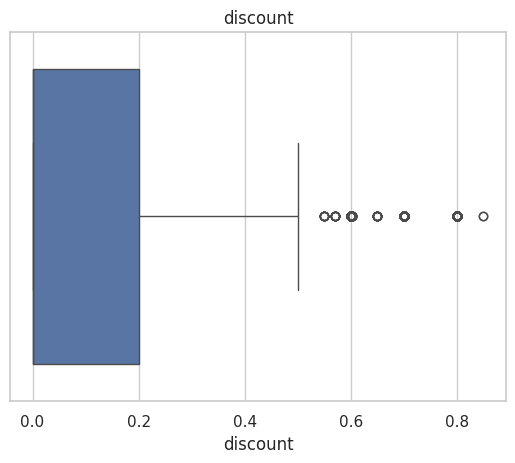

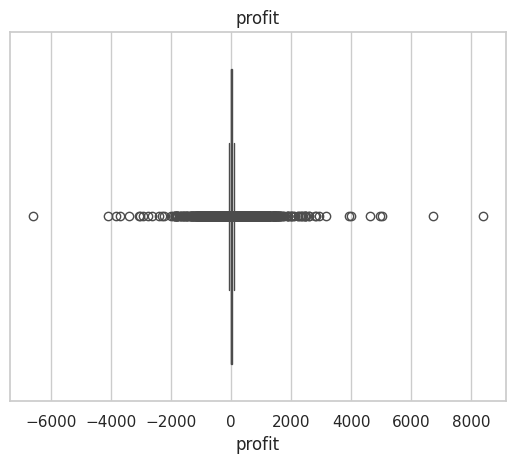

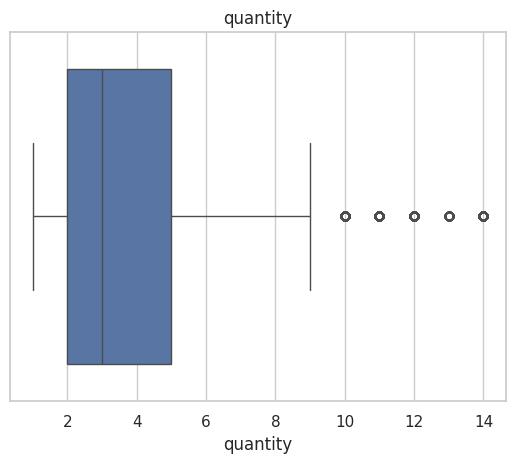

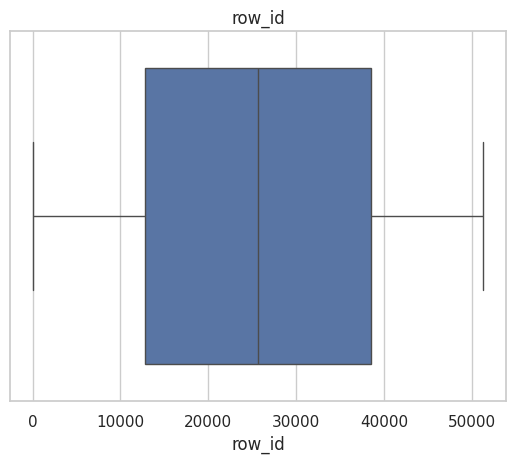

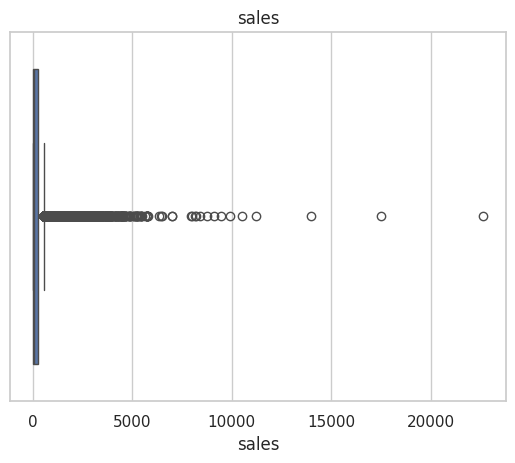

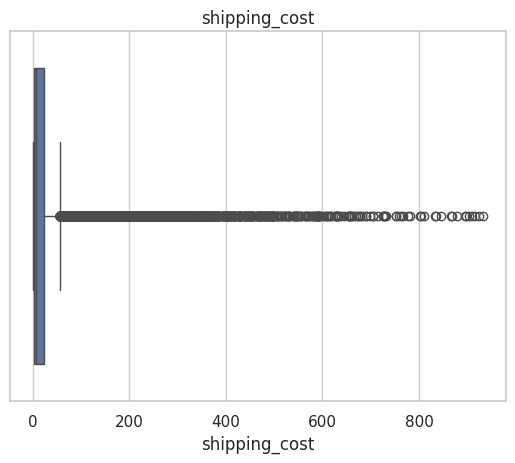

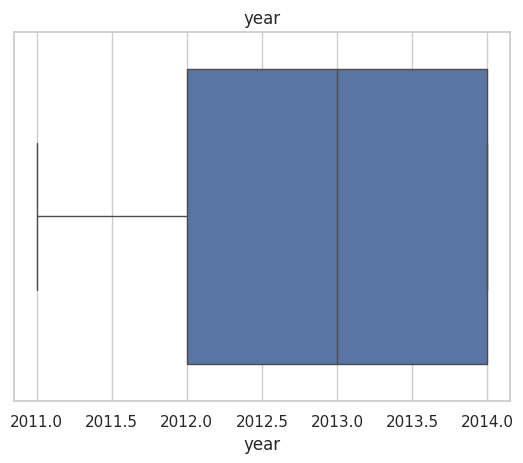

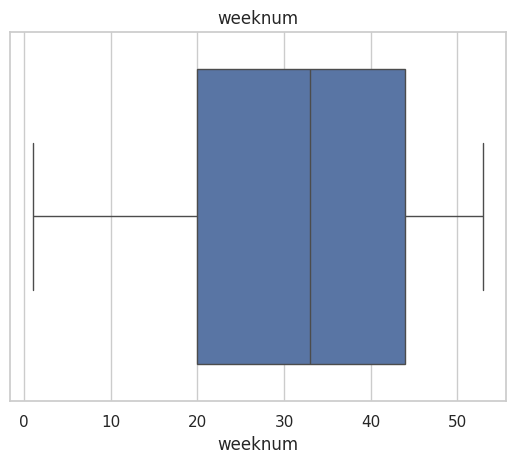

In [27]:
# Q2: UNIVARIATE ANALYSIS
num_cols = df.select_dtypes(include=np.number).columns

# Summary
print(df[num_cols].describe())

# Histograms
df[num_cols].hist(figsize=(12,10))
plt.tight_layout()
plt.show()

# Boxplots
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

i. Useless Features:
row_id, order_id, customer_id, and product_id are identifiers and do not provide analytical value.

ii. Distribution:
sales and profit are not normally distributed.
quantity is relatively discrete.

iii. Skewness:
sales and profit are right-skewed, meaning a few high value orders dominate.
This indicates uneven revenue contribution.

iv. Outliers:
Significant outliers are present in sales, profit, and shipping_cost.
These can influence averages and should be handled carefully.

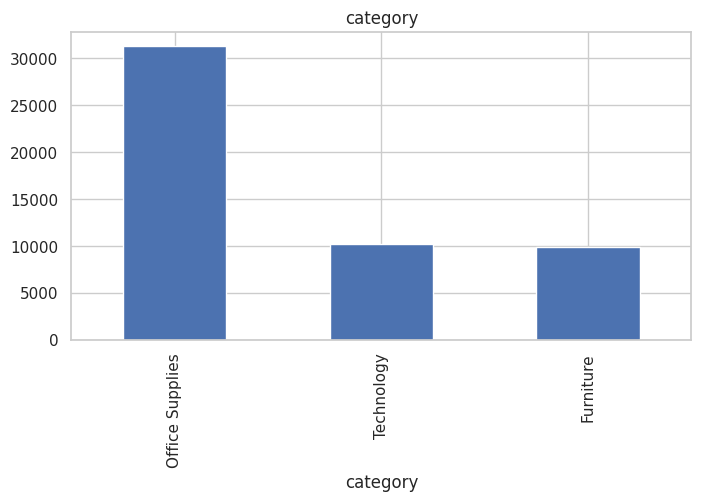

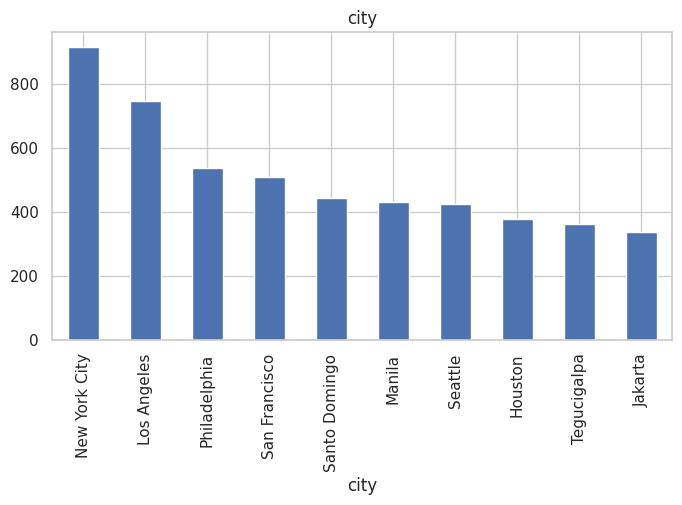

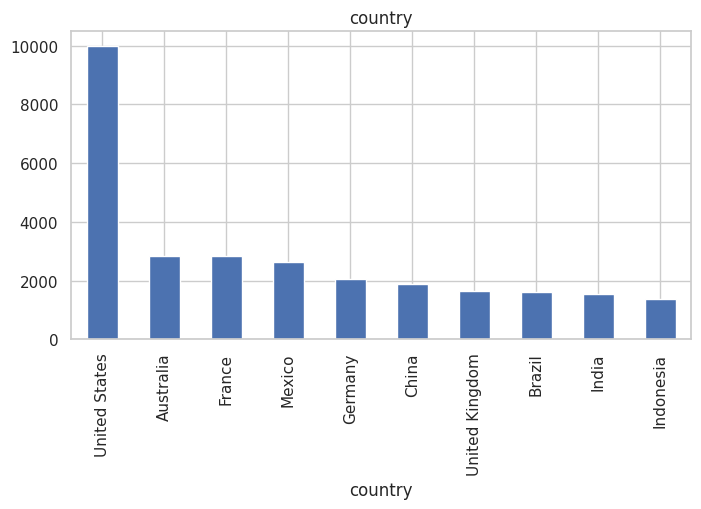

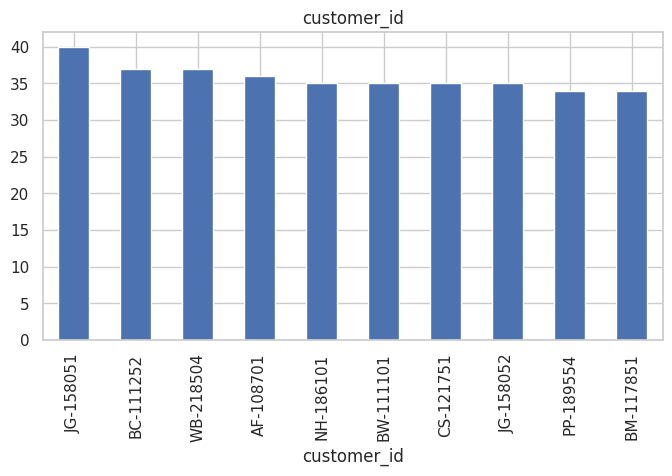

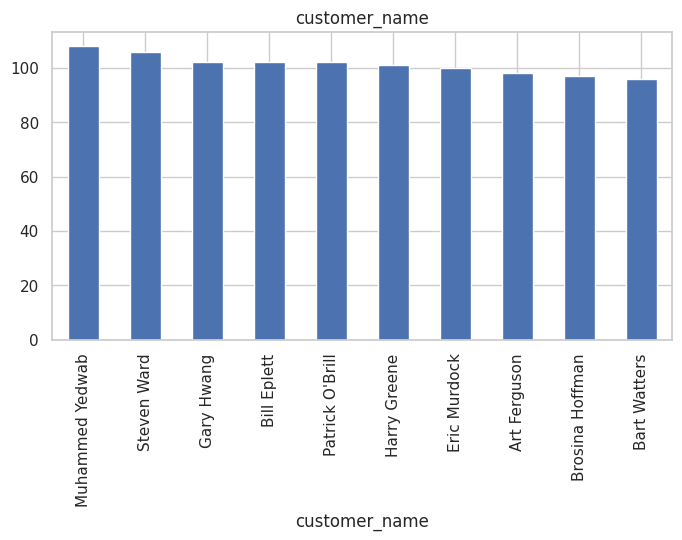

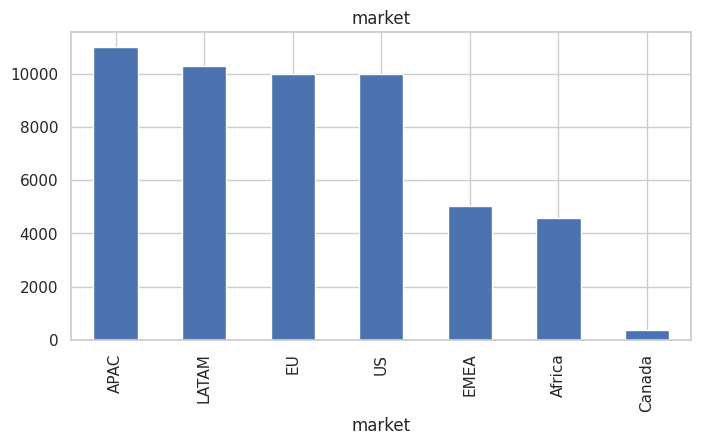

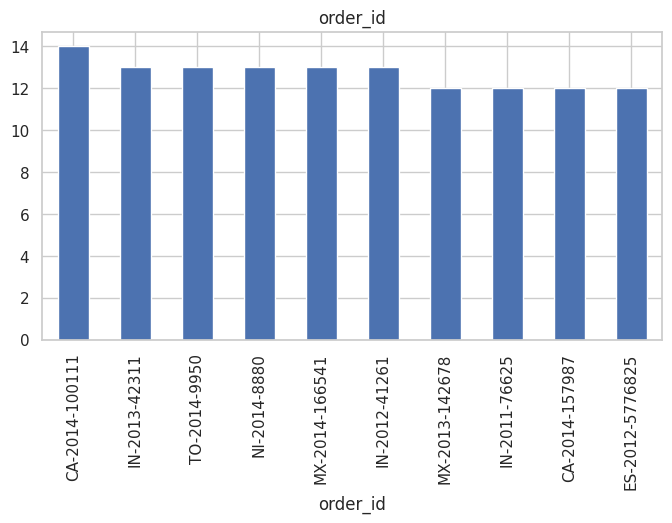

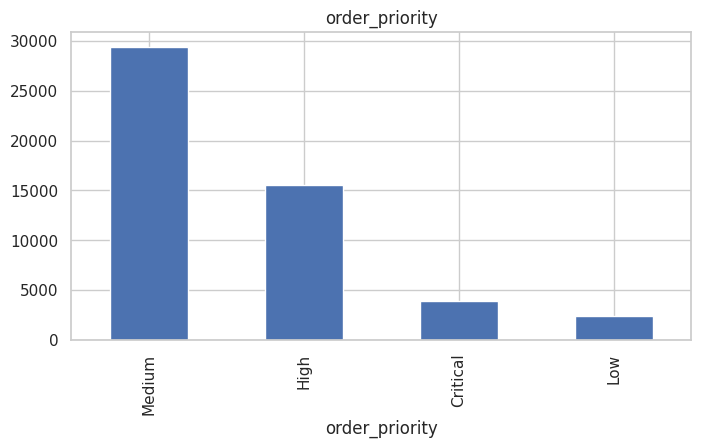

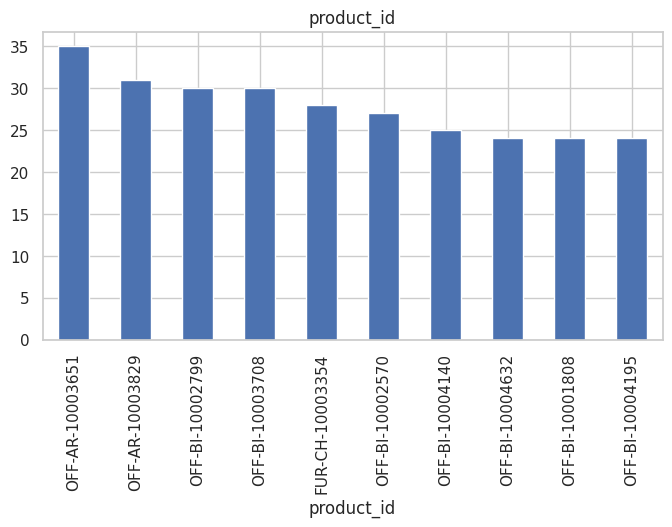

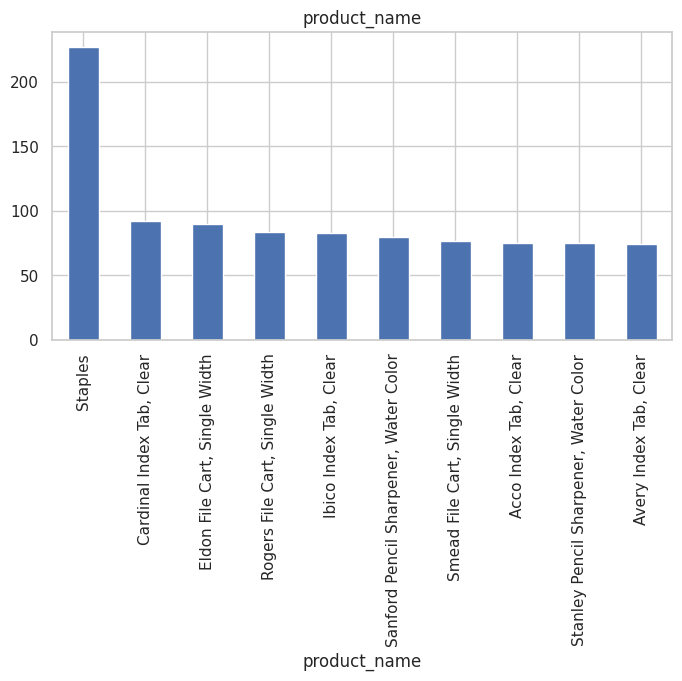

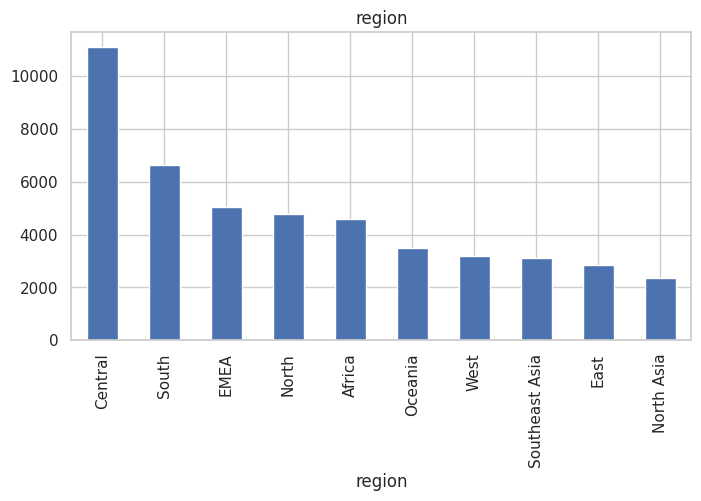

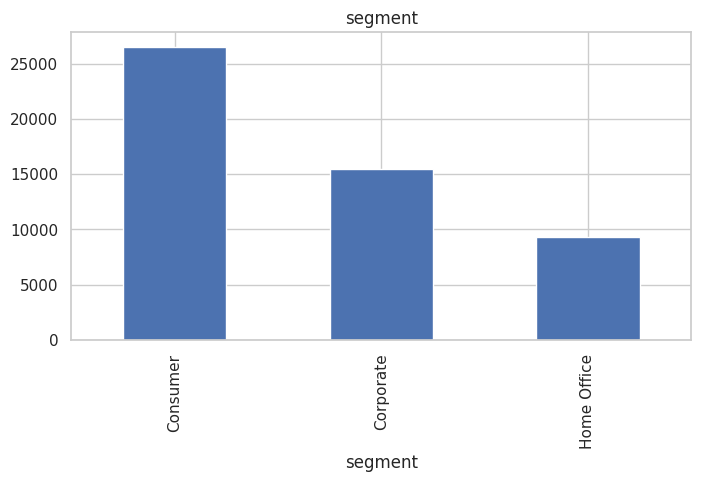

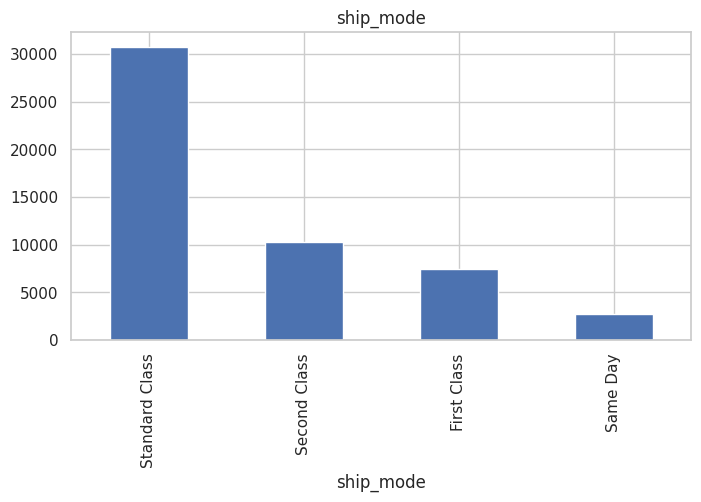

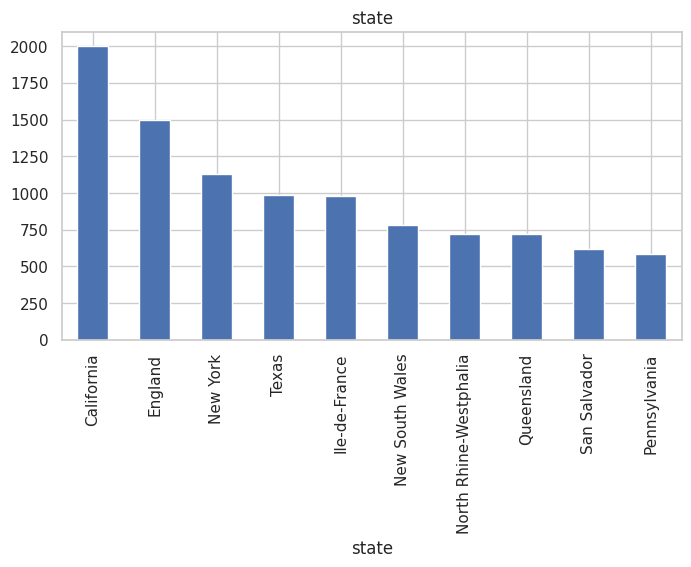

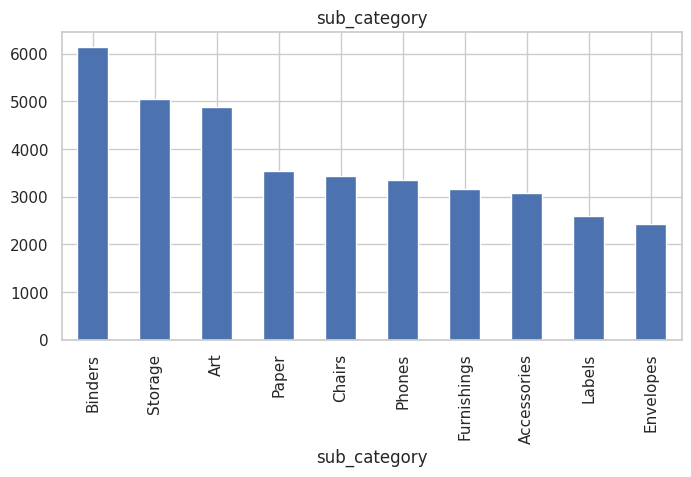

In [28]:
# Q3: UNIVARIATE ANALYSIS
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    plt.figure(figsize=(8,4))
    df[col].value_counts().head(10).plot(kind='bar')
    plt.title(col)
    plt.show()

i. Inaccurate Features:
customer_name is not useful for modeling due to high uniqueness.

ii. Issue with Customer Name:
It creates too many unique categories which leads to overfitting and bad generalization.

iii. Category Distribution:
Categories are imbalanced, with some dominating more than others.

iv. Country Dominance:
A few countries contribute the majority of orders, indicating market concentration.

v. City Distribution:
Orders are concentrated in a few cities rather than  evenly distributed.

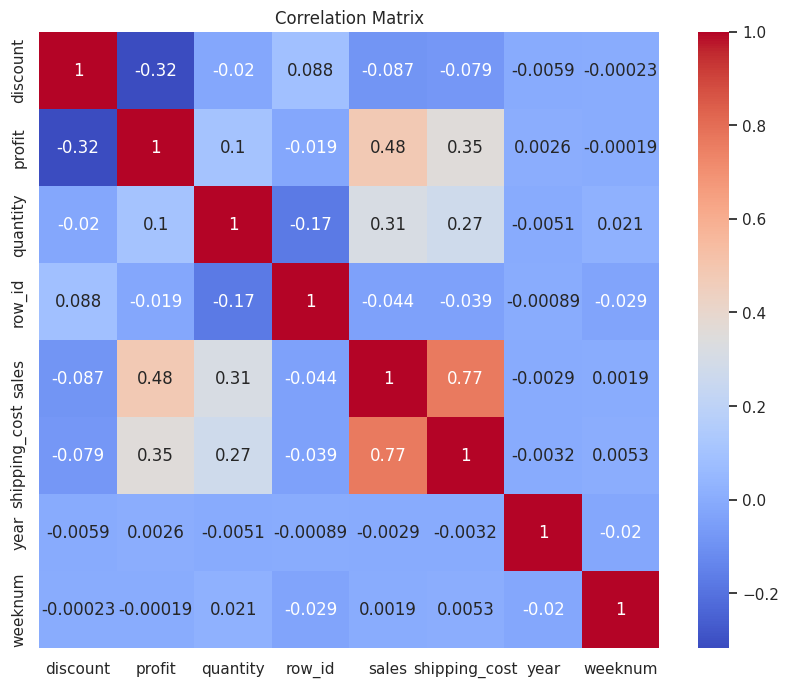

In [29]:
# Q4: BIVARIATE
corr = df[num_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

i. Strong Correlation:
sales and profit show positive correlation.

ii. Negative Correlation:
discount and profit often show negative correlation → higher discounts reduce profit.

iii. Useful Next Checks:
discount vs profit
sales vs shipping_cost

iv. Time Effects:
Sales tend to increase over time, possibly due to seasonal demand or business growth.

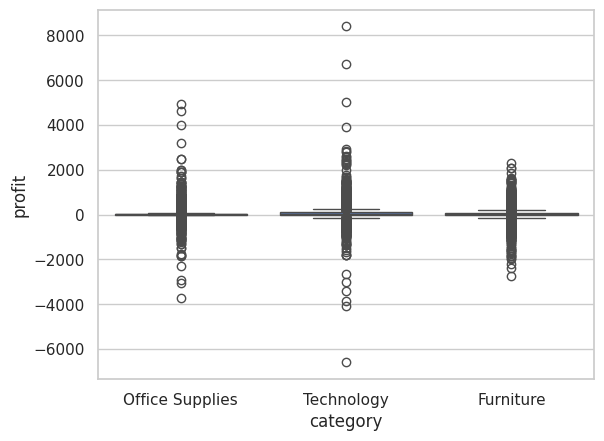

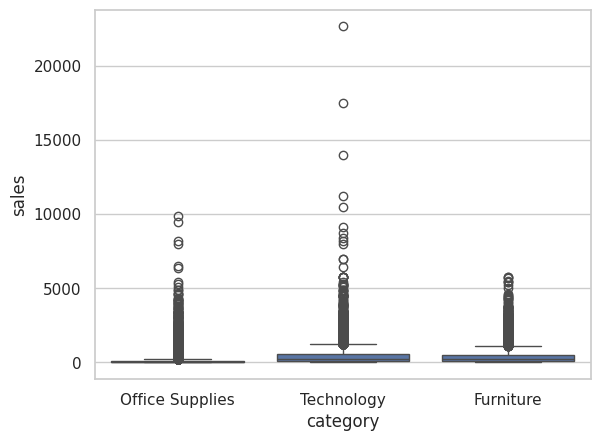

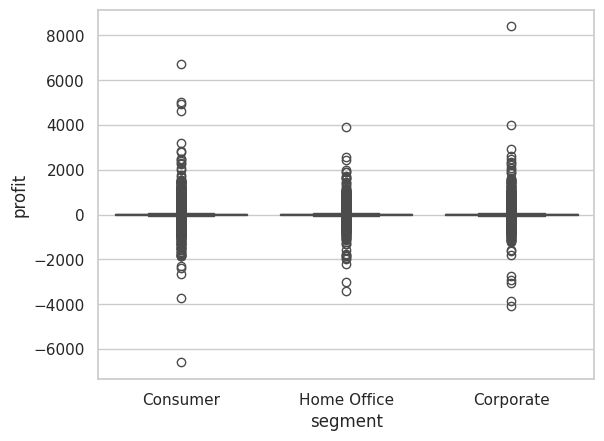

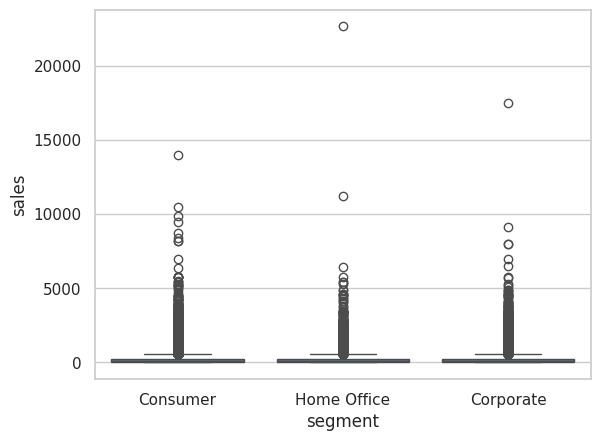

In [30]:
# Q5: CATEGORICAL vs NUMERICAL
# Profit by Category
sns.boxplot(x='category', y='profit', data=df)
plt.show()

# Sales by Category
sns.boxplot(x='category', y='sales', data=df)
plt.show()

# Profit by Segment
sns.boxplot(x='segment', y='profit', data=df)
plt.show()

# Sales by Segment
sns.boxplot(x='segment', y='sales', data=df)
plt.show()

i. Profit by Category:
Highest median profit → Usually Technology
Lowest → Furniture
Wide IQR → Indicates inconsistent profit

ii. Sales by Category:
Technology has highest sales
It also often has high profit → strong segment

iii. Profit by Segment:
Corporate or Consumer segments often perform best
Some segments show negative outliers → loss-making orders

iv. Sales by Segment:
Consumer segment usually dominates sales
Profit trend is mostly consistent but not perfectly aligned

In [31]:
# Q6: MARKET ANALYSIS
# Market vs Region
pd.crosstab(df['market'], df['region'])

# Country with lowest orders
df['country'].value_counts().tail()

,count
country,
Bahrain,2
Swaziland,2
Eritrea,2
South Sudan,2
Burundi,2


i. Market Distribution:
Market is not evenly distributed across regions and certain regions dominate.

ii. Country with Low Orders:
Some countries contribute negligible sales and potential expansion opportunity.

iii. Key Insights:
Business is highly concentrated geographically
Discounts reduce profit significantly
A small number of orders drive large revenue